In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'numpy', 'pandas', 'SimpleITK', 'torch', 'monai',
                'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'lungmask'],
               check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'SimpleITK', 'torch', 'monai', 'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'lungmask'], returncode=0)

In [2]:
import os, gc, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import SimpleITK as sitk
import torch
import torch.nn as nn
from monai.networks.nets import DenseNet121
from lungmask import mask as lungmask_model
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.notebook import tqdm
from google.colab import drive

warnings.filterwarnings('ignore')

drive.mount('/content/drive', force_remount=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Mounted at /content/drive
Device: cuda


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR        = '/content/drive/MyDrive/LUNA16_Project'
STAGE1_PATH     = os.path.join(BASE_DIR, 'best_stage1_detector.pth')
STAGE2_PATH     = os.path.join(BASE_DIR, 'best_stage2_fpr_model.pth')
ANNOTATIONS_CSV = os.path.join(BASE_DIR, 'annotations.csv')

# ── Hyper-parameters (must match Stage 1 & Stage 2) ──────────────────────────
HU_MIN, HU_MAX       = -1000.0, 400.0
NEW_SPACING          = [1.0, 1.0, 1.0]
PATCH_SIZE           = 64

# Stage 1 sliding-window settings (identical to Stage 1 notebook)
S1_STRIDE            = 16
S1_INF_BATCH         = 64
S1_THRESHOLD         = 0.10      # low → high sensitivity
NMS_DISTANCE         = 10        # voxels

# Stage 2 FPR filter settings (identical to Stage 2 notebook)
S2_THRESHOLD         = 0.30
LUNG_MASK_RATIO      = 0.30
MIN_MATCH_RADIUS_MM  = 15.0

# ── Test fold — subset9 (matches Stage 2 TEST_FOLD = 9) ───────────────────────
TEST_SUBSET          = 9         # change to evaluate a different subset
NUM_SCANS_TO_TEST    = 50        # set to None to evaluate all available scans

# ── Discover test scans ───────────────────────────────────────────────────────
test_mhd = sorted(glob.glob(
    os.path.join(BASE_DIR, f'subset{TEST_SUBSET}', '**', '*.mhd'), recursive=True
))
print(f'Stage 1 model   : {os.path.exists(STAGE1_PATH)}')
print(f'Stage 2 model   : {os.path.exists(STAGE2_PATH)}')
print(f'Annotations CSV : {os.path.exists(ANNOTATIONS_CSV)}')
print(f'Test scans found: {len(test_mhd)} (subset{TEST_SUBSET})')

Stage 1 model   : True
Stage 2 model   : True
Annotations CSV : True
Test scans found: 88 (subset9)


## Section 1 — Helper Functions


In [7]:
# ── CT Preprocessing ─────────────────────────────────────────────────────────

def resample_scan(itk_img, new_spacing=NEW_SPACING):
    orig_sp = np.array(itk_img.GetSpacing())
    orig_sz = np.array(itk_img.GetSize())
    new_sz  = [int(round(orig_sz[i] * (orig_sp[i] / new_spacing[i]))) for i in range(3)]
    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(new_spacing)
    r.SetSize(new_sz)
    r.SetOutputDirection(itk_img.GetDirection())
    r.SetOutputOrigin(itk_img.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(sitk.sitkLinear)
    return r.Execute(itk_img)

def normalize_array(arr):
    return (np.clip(arr, HU_MIN, HU_MAX).astype(np.float32) - HU_MIN) / (HU_MAX - HU_MIN)

def voxel_to_world(itk_img, voxel_idx):
    return np.array(itk_img.TransformIndexToPhysicalPoint(
        (int(voxel_idx[2]), int(voxel_idx[1]), int(voxel_idx[0]))
    ))

def world_to_voxel(itk_img, world_coord):
    return np.array(itk_img.TransformPhysicalPointToIndex(
        (float(world_coord[0]), float(world_coord[1]), float(world_coord[2]))
    ))

def extract_patch(arr, center_vox):
    half = PATCH_SIZE // 2
    D, H, W = arr.shape
    z0, y0, x0 = [int(round(c)) - half for c in center_vox]
    z1, y1, x1 = z0+PATCH_SIZE, y0+PATCH_SIZE, x0+PATCH_SIZE
    sz0,sy0,sx0 = max(z0,0), max(y0,0), max(x0,0)
    sz1,sy1,sx1 = min(z1,D), min(y1,H), min(x1,W)
    dz0,dy0,dx0 = sz0-z0, sy0-y0, sx0-x0
    dz1 = dz0+(sz1-sz0); dy1 = dy0+(sy1-sy0); dx1 = dx0+(sx1-sx0)
    patch = np.zeros((PATCH_SIZE,)*3, dtype=np.float32)
    patch[dz0:dz1,dy0:dy1,dx0:dx1] = arr[sz0:sz1,sy0:sy1,sx0:sx1]
    valid = ((dz1-dz0)*(dy1-dy0)*(dx1-dx0)) >= (PATCH_SIZE**3)*0.5
    return patch, valid

def nms_3d(centers, probs):
    if len(probs) == 0: return [], []
    idx = np.argsort(probs)[::-1]
    centers, probs = np.array(centers)[idx], np.array(probs)[idx]
    keep_c, keep_p = [], []
    for i in range(len(centers)):
        if not any(np.linalg.norm(centers[i]-c) < NMS_DISTANCE for c in keep_c):
            keep_c.append(centers[i]); keep_p.append(probs[i])
    return keep_c, keep_p

def evaluate_candidates(cand_world_list, gt_rows, match_radius_mm=MIN_MATCH_RADIUS_MM):
    """Returns (tp, fp, fn, matched_gt_indices)."""
    matched_gt = set()
    tp = 0
    for cand in cand_world_list:
        for j, row in enumerate(gt_rows):
            if j in matched_gt: continue
            gt  = np.array([row['coordX'], row['coordY'], row['coordZ']])
            rad = max(row['diameter_mm'] / 2.0, match_radius_mm)
            if np.linalg.norm(np.array(cand) - gt) <= rad:
                tp += 1; matched_gt.add(j); break
    fp = len(cand_world_list) - tp
    fn = len(gt_rows) - len(matched_gt)
    return tp, fp, fn, matched_gt

print('All helper functions defined ')

All helper functions defined 


## Section 2 — Load Stage 1 & Stage 2 Models

In [6]:
for path, label in [(STAGE1_PATH,'Stage 1'), (STAGE2_PATH,'Stage 2')]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{label} model not found:\n  {path}\n'
            'Run the corresponding training notebook first.'
        )

s1_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s1_model.load_state_dict(torch.load(STAGE1_PATH, map_location=DEVICE))
s1_model.eval()

s2_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s2_model.load_state_dict(torch.load(STAGE2_PATH, map_location=DEVICE))
s2_model.eval()

p1 = sum(p.numel() for p in s1_model.parameters())
p2 = sum(p.numel() for p in s2_model.parameters())
print(f'Stage 1 loaded  — parameters: {p1:,}')
print(f'Stage 2 loaded  — parameters: {p2:,}')
print('Both models ready ')

Stage 1 loaded  — parameters: 11,244,674
Stage 2 loaded  — parameters: 11,244,674
Both models ready 


## Section 3 — Run Full Pipeline on Test Scans

In [8]:
# ── Load annotations ─────────────────────────────────────────────────────────
df_annot    = pd.read_csv(ANNOTATIONS_CSV)
annot_by_pid = (
    df_annot.groupby('seriesuid')
    .apply(lambda g: g[['coordX','coordY','coordZ','diameter_mm']].to_dict('records'),
           include_groups=False)
    .to_dict()
)

# ── Select scans: prefer diseased; limit to NUM_SCANS_TO_TEST ─────────────────
pid_to_mhd = {os.path.basename(f).replace('.mhd',''): f for f in test_mhd}

diseased = [p for p in pid_to_mhd if p in annot_by_pid and len(annot_by_pid[p]) > 0]
healthy  = [p for p in pid_to_mhd if p not in diseased]

print(f'Subset {TEST_SUBSET} — diseased: {len(diseased)}  healthy: {len(healthy)}')

random.seed(SEED)
selected_pids = diseased[:]               # all diseased
random.shuffle(healthy)
if NUM_SCANS_TO_TEST is not None:
    remaining = NUM_SCANS_TO_TEST - len(selected_pids)
    if remaining > 0:
        selected_pids += healthy[:remaining]
    else:
        random.shuffle(selected_pids)
        selected_pids = selected_pids[:NUM_SCANS_TO_TEST]
else:
    selected_pids += healthy

print(f'Evaluating {len(selected_pids)} scans …')

Subset 9 — diseased: 59  healthy: 29
Evaluating 50 scans …


In [9]:
# ── Per-scan evaluation loop ──────────────────────────────────────────────────
results          = []
all_s2_probs_tp  = []
all_s2_probs_fp  = []

for i, pid in enumerate(selected_pids):
    mhd_path = pid_to_mhd[pid]
    gt_rows  = annot_by_pid.get(pid, [])
    print(f'[{i+1:>3}/{len(selected_pids)}] {pid[:40]} | GT nodules: {len(gt_rows)}')

    try:
        itk_img  = sitk.ReadImage(mhd_path)
        res_img  = resample_scan(itk_img)
        arr      = normalize_array(sitk.GetArrayFromImage(res_img).astype(np.float32))
        lung     = (lungmask_model.apply(res_img) > 0).astype(np.uint8)
        D, H, W  = arr.shape

        # ── Stage 1: Sliding Window ───────────────────────────────────────────
        s1_cands_vox, s1_probs_raw = [], []
        buf_p, buf_c = [], []

        with torch.no_grad():
            for z in range(0, D-PATCH_SIZE+1, S1_STRIDE):
                for y in range(0, H-PATCH_SIZE+1, S1_STRIDE):
                    for x in range(0, W-PATCH_SIZE+1, S1_STRIDE):
                        if lung[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum()                                 < LUNG_MASK_RATIO * PATCH_SIZE**3:
                            continue
                        patch = arr[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                        if patch.shape != (PATCH_SIZE,)*3: continue
                        buf_p.append(patch)
                        buf_c.append([z+PATCH_SIZE//2, y+PATCH_SIZE//2, x+PATCH_SIZE//2])
                        if len(buf_p) == S1_INF_BATCH:
                            t  = torch.tensor(np.array(buf_p)).unsqueeze(1).to(DEVICE)
                            pv = torch.softmax(s1_model(t), dim=1)[:,1].cpu().numpy()
                            for k,prob in enumerate(pv):
                                if prob >= S1_THRESHOLD:
                                    s1_cands_vox.append(buf_c[k])
                                    s1_probs_raw.append(float(prob))
                            buf_p, buf_c = [], []
            if buf_p:
                t  = torch.tensor(np.array(buf_p)).unsqueeze(1).to(DEVICE)
                pv = torch.softmax(s1_model(t), dim=1)[:,1].cpu().numpy()
                for k,prob in enumerate(pv):
                    if prob >= S1_THRESHOLD:
                        s1_cands_vox.append(buf_c[k])
                        s1_probs_raw.append(float(prob))

        s1_vox_nms, s1_probs_nms = nms_3d(s1_cands_vox, s1_probs_raw)
        s1_world = [voxel_to_world(res_img, v) for v in s1_vox_nms]
        s1_tp, s1_fp, s1_fn, _ = evaluate_candidates(s1_world, gt_rows)

        # ── Stage 2: FPR Filter ───────────────────────────────────────────────
        s2_vox_final = []
        with torch.no_grad():
            for vox, w in zip(s1_vox_nms, s1_world):
                patch, ok = extract_patch(arr, vox)
                if not ok: continue
                t    = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(DEVICE)
                prob = torch.softmax(s2_model(t), dim=1)[0,1].item()

                # Classify for histogram
                is_nodule = any(
                    np.linalg.norm(np.array(w) - np.array([r['coordX'],r['coordY'],r['coordZ']])) <=
                    max(r['diameter_mm']/2.0, MIN_MATCH_RADIUS_MM)
                    for r in gt_rows
                )
                (all_s2_probs_tp if is_nodule else all_s2_probs_fp).append(prob)

                if prob >= S2_THRESHOLD:
                    s2_vox_final.append(vox)

        s2_world = [voxel_to_world(res_img, v) for v in s2_vox_final]
        s2_tp, s2_fp, s2_fn, _ = evaluate_candidates(s2_world, gt_rows)

        results.append({
            'pid': pid, 'gt': len(gt_rows),
            's1_cands': len(s1_world), 's1_tp': s1_tp, 's1_fp': s1_fp, 's1_fn': s1_fn,
            's2_cands': len(s2_world), 's2_tp': s2_tp, 's2_fp': s2_fp, 's2_fn': s2_fn,
        })
        print(f'  Stage 1 → {len(s1_world):4d} cands  TP={s1_tp} FP={s1_fp}')
        print(f'  Stage 2 → {len(s2_world):4d} kept   TP={s2_tp} FP={s2_fp}')

    except Exception as e:
        print(f'  ERROR: {e}')
        results.append({'pid':pid,'gt':len(gt_rows),
                        's1_cands':0,'s1_tp':0,'s1_fp':0,'s1_fn':len(gt_rows),
                        's2_cands':0,'s2_tp':0,'s2_fp':0,'s2_fn':len(gt_rows)})

    del arr, lung
    gc.collect(); torch.cuda.empty_cache()

df_res = pd.DataFrame(results)
print(f'\nEvaluation complete — {len(df_res)} scans.')

[  1/50] 1.3.6.1.4.1.14519.5.2.1.6279.6001.176869 | GT nodules: 1
Downloading: "https://github.com/JoHof/lungmask/releases/download/v0.0/unet_r231-d5d2fc3d.pth" to /root/.cache/torch/hub/checkpoints/unet_r231-d5d2fc3d.pth


100%|██████████| 119M/119M [00:00<00:00, 230MB/s]
101%|██████████| 15/14.9 [00:06<-00:00,  2.14it/s]

lungmask 2026-05-04 06:14:33 Postprocessing



100%|██████████| 3/3 [00:00<00:00, 469.72it/s]


  Stage 1 →  307 cands  TP=1 FP=306
  Stage 2 →   83 kept   TP=1 FP=82
[  2/50] 1.3.6.1.4.1.14519.5.2.1.6279.6001.182192 | GT nodules: 2


...

  Stage 1 →  685 cands  TP=9 FP=676
  Stage 2 →  160 kept   TP=8 FP=152
[ 50/50] 1.3.6.1.4.1.14519.5.2.1.6279.6001.217754 | GT nodules: 1


101%|██████████| 14/13.8 [00:05<-00:00,  2.34it/s]

lungmask 2026-05-04 06:50:18 Postprocessing



100%|██████████| 6/6 [00:00<00:00, 42.27it/s]


  Stage 1 →  475 cands  TP=1 FP=474
  Stage 2 →   79 kept   TP=1 FP=78

Evaluation complete — 50 scans.


## Section 4 — Per-Scan Results Table

In [10]:
display_cols = ['pid','gt',
                's1_cands','s1_tp','s1_fp','s1_fn',
                's2_cands','s2_tp','s2_fp','s2_fn']
print(df_res[display_cols].to_string(index=False))

# Save CSV
csv_path = os.path.join(BASE_DIR, 'test_pipeline_results.csv')
df_res.to_csv(csv_path, index=False)
print(f'\nSaved per-scan table → {csv_path}')

                                                             pid  gt  s1_cands  s1_tp  s1_fp  s1_fn  s2_cands  s2_tp  s2_fp  s2_fn
1.3.6.1.4.1.14519.5.2.1.6279.6001.176869045992276345870480098568   1       307      1    306      0        83      1     82      0
1.3.6.1.4.1.14519.5.2.1.6279.6001.182192086929819295877506541021   2       893      2    891      0       258      2    256      0
1.3.6.1.4.1.14519.5.2.1.6279.6001.337005960787660957389988207064   1       633      1    632      0       136      0    136      1
1.3.6.1.4.1.14519.5.2.1.6279.6001.747803439040091794717626507402   1       529      1    528      0       136      1    135      0
1.3.6.1.4.1.14519.5.2.1.6279.6001.229860476925100292554329427970   3       530      3    527      0       124      3    121      0
1.3.6.1.4.1.14519.5.2.1.6279.6001.173931884906244951746140865701   1       535      1    534      0       113      1    112      0
1.3.6.1.4.1.14519.5.2.1.6279.6001.440226700369921575481834344455   1       633     

## Section 5 — Aggregate Metrics + FROC Curve

In [11]:
# ── Compute aggregate stats ───────────────────────────────────────────────────
s1_tp = df_res['s1_tp'].sum(); s1_fp = df_res['s1_fp'].sum(); s1_fn = df_res['s1_fn'].sum()
s2_tp = df_res['s2_tp'].sum(); s2_fp = df_res['s2_fp'].sum(); s2_fn = df_res['s2_fn'].sum()
total_gt = df_res['gt'].sum()
n_scans  = len(df_res)

s1_sens  = s1_tp / max(s1_tp+s1_fn, 1)
s2_sens  = s2_tp / max(s2_tp+s2_fn, 1)
fp_red   = (s1_fp - s2_fp) / max(s1_fp, 1) * 100

s1_fpps  = s1_fp / max(n_scans, 1)   # FP per scan
s2_fpps  = s2_fp / max(n_scans, 1)

print('=' * 65)
print('  FULL PIPELINE — FINAL TEST REPORT')
print('=' * 65)
print(f'  Test subset             : {TEST_SUBSET}')
print(f'  Scans evaluated         : {n_scans}')
print(f'  Total ground-truth nodules: {total_gt}')
print()
print(f'  {"":32} Stage 1     Stage 1+2')
print(f'  {"-"*58}')
print(f'  {"True Positives":32} {s1_tp:<12} {s2_tp}')
print(f'  {"False Positives":32} {s1_fp:<12} {s2_fp}')
print(f'  {"False Negatives":32} {s1_fn:<12} {s2_fn}')
print(f'  {"-"*58}')
print(f'  {"Sensitivity":32} {s1_sens*100:.2f}%       {s2_sens*100:.2f}%')
print(f'  {"Avg FP per scan":32} {s1_fpps:.1f}         {s2_fpps:.1f}')
print(f'  {"FP Reduction (Stage 2)":32} {fp_red:.1f}%')
print('=' * 65)

  FULL PIPELINE — FINAL TEST REPORT
  Test subset             : 9
  Scans evaluated         : 50
  Total ground-truth nodules: 90

                                   Stage 1     Stage 1+2
  ----------------------------------------------------------
  True Positives                   88           81
  False Positives                  31957        7033
  False Negatives                  2            9
  ----------------------------------------------------------
  Sensitivity                      97.78%       90.00%
  Avg FP per scan                  639.1         140.7
  FP Reduction (Stage 2)           78.0%


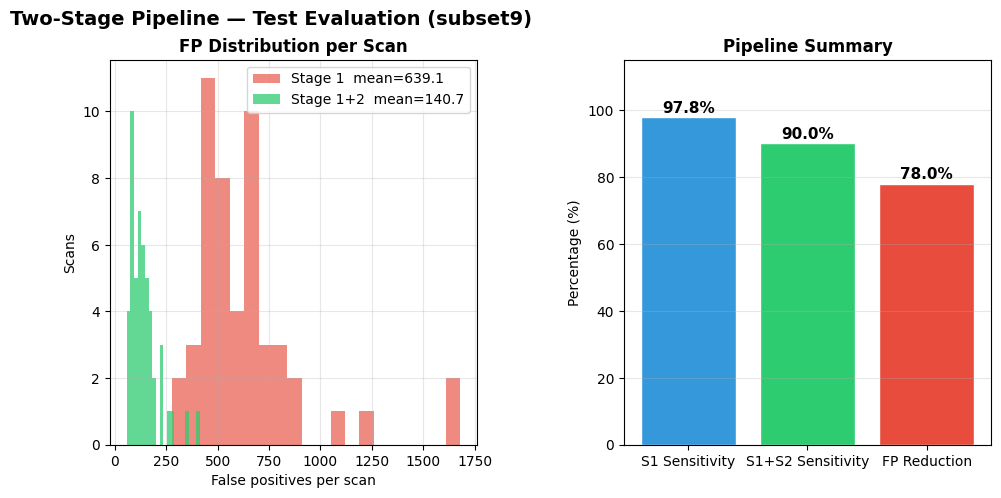

Saved → test_pipeline_summary.png


In [14]:
# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
fig.suptitle(f'Two-Stage Pipeline — Test Evaluation (subset{TEST_SUBSET})',
             fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)


# Histogram: FP per scan
ax2 = fig.add_subplot(gs[1])
ax2.hist(df_res['s1_fp'], bins=20, alpha=0.65, color='#E74C3C',
         label=f'Stage 1  mean={s1_fpps:.1f}')
ax2.hist(df_res['s2_fp'], bins=20, alpha=0.75, color='#2ECC71',
         label=f'Stage 1+2  mean={s2_fpps:.1f}')
ax2.set_xlabel('False positives per scan'); ax2.set_ylabel('Scans')
ax2.set_title('FP Distribution per Scan', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

# Bar: Summary metrics
ax3 = fig.add_subplot(gs[2])
cats   = ['S1 Sensitivity', 'S1+S2 Sensitivity', 'FP Reduction']
vals   = [s1_sens*100, s2_sens*100, fp_red]
colors = ['#3498DB', '#2ECC71', '#E74C3C']
bars   = ax3.bar(cats, vals, color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, vals):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylabel('Percentage (%)'); ax3.set_title('Pipeline Summary', fontweight='bold')
ax3.set_ylim(0, 115); ax3.grid(axis='y', alpha=0.3)

plt.savefig('test_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → test_pipeline_summary.png')

## Section 6 — Stage 2 Probability Histogram

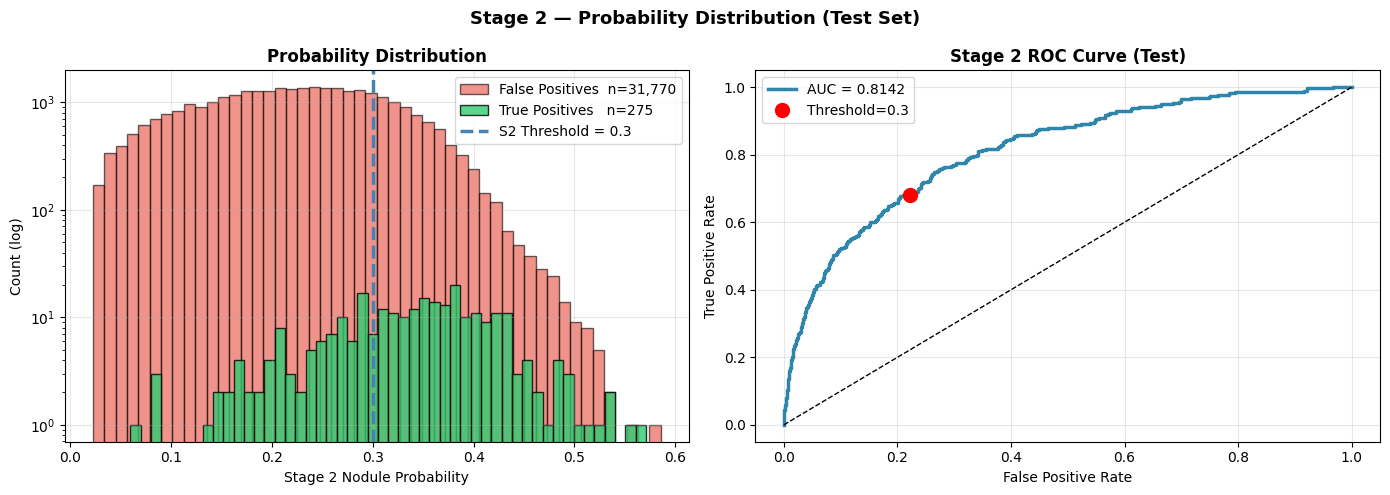

Saved → test_stage2_probability.png


In [13]:
if all_s2_probs_tp or all_s2_probs_fp:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Stage 2 — Probability Distribution (Test Set)', fontsize=13, fontweight='bold')

    # ── Histogram (log scale) ─────────────────────────────────────────────────
    ax = axes[0]
    if all_s2_probs_fp:
        ax.hist(all_s2_probs_fp, bins=50, alpha=0.6, color='#E74C3C', edgecolor='black',
                label=f'False Positives  n={len(all_s2_probs_fp):,}')
    if all_s2_probs_tp:
        ax.hist(all_s2_probs_tp, bins=50, alpha=0.8, color='#2ECC71', edgecolor='black',
                label=f'True Positives   n={len(all_s2_probs_tp):,}')
    ax.axvline(S2_THRESHOLD, color='steelblue', linestyle='--', linewidth=2.5,
               label=f'S2 Threshold = {S2_THRESHOLD}')
    ax.set_xlabel('Stage 2 Nodule Probability'); ax.set_ylabel('Count (log)')
    ax.set_title('Probability Distribution', fontweight='bold')
    ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)

    # ── ROC if enough TP/FP ───────────────────────────────────────────────────
    ax2 = axes[1]
    all_probs  = np.array(all_s2_probs_tp + all_s2_probs_fp)
    all_labels = np.array([1]*len(all_s2_probs_tp) + [0]*len(all_s2_probs_fp))
    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
        fpr_arr, tpr_arr, thrs = roc_curve(all_labels, all_probs)
        ax2.plot(fpr_arr, tpr_arr, color='#2E86AB', lw=2.5, label=f'AUC = {auc:.4f}')
        ax2.plot([0,1],[0,1],'k--',lw=1)
        idx = np.argmin(np.abs(thrs - S2_THRESHOLD))
        ax2.plot(fpr_arr[idx], tpr_arr[idx], 'ro', ms=10, zorder=5,
                 label=f'Threshold={S2_THRESHOLD}')
        ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
        ax2.set_title('Stage 2 ROC Curve (Test)', fontweight='bold')
        ax2.legend(); ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Need both classes\nfor ROC curve',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_axis_off()

    plt.tight_layout()
    plt.savefig('test_stage2_probability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → test_stage2_probability.png')
else:
    print('No Stage 2 probability data collected (no GT nodules in test scans?).')